In [3]:
pip install ucimlrepo

In [4]:
# ── SECCIÓN 2: Análisis Exploratorio ──────────────────────────────────────────
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
ds = fetch_ucirepo(id=235)

# Todo viene en features para este dataset
df = ds.data.features.copy()

# Convertir a numérico ('?' es el valor missing original)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nEstadísticas descriptivas:")
print(df.describe().round(3))

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Shape: (2075259, 9)

Columnas: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Estadísticas descriptivas:
       Date  Time  Global_active_power  Global_reactive_power     Voltage  \
count   0.0   0.0          2049280.000            2049280.000  2049280.00   
mean    NaN   NaN                1.092                  0.124      240.84   
std     NaN   NaN                1.057                  0.113        3.24   
min     NaN   NaN                0.076                  0.000      223.20   
25%     NaN   NaN                0.308                  0.048      238.99   
50%     NaN   NaN                0.602                  0.100      241.01   
75%     NaN   NaN                1.528                  0.194      242.89   
max     NaN   NaN               11.122                  1.390      254.15   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count       2049280.000

In [5]:
# ── SECCIÓN 3: Preprocesamiento ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target_col = 'Global_active_power'

# Variables a usar (descartamos Date y Time si estuvieran en X)
feature_cols = ['Global_reactive_power', 'Voltage', 'Global_intensity',
                'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

df_clean = df[feature_cols + [target_col]].dropna()
print(f"Filas tras eliminar NaN: {len(df_clean):,} (de {len(df):,})")
print(f"NaN eliminados: {len(df) - len(df_clean):,} ({(1 - len(df_clean)/len(df))*100:.2f}%)")

X_model = df_clean[feature_cols]
y_model = df_clean[target_col]

# Train/test split 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42)

# Escalado
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain: {X_train_sc.shape} | Test: {X_test_sc.shape}")

Filas tras eliminar NaN: 2,049,280 (de 2,075,259)
NaN eliminados: 25,979 (1.25%)

Train: (1639424, 6) | Test: (409856, 6)


# Regresion Lineal

In [6]:
# ── SECCIÓN 4: Regresión Lineal ───────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

# Predicciones
y_pred_train = lr.predict(X_train_sc)
y_pred_test  = lr.predict(X_test_sc)

def evaluar(y_true, y_pred, split):
    r2  = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"[{split}]  R²={r2:.4f}  MSE={mse:.4f}  MAE={mae:.4f}")

evaluar(y_train, y_pred_train, 'TRAIN')
evaluar(y_test,  y_pred_test,  'TEST ')

print("\nCoeficientes:")
for feat, coef in zip(feature_cols, lr.coef_):
    print(f"  {feat:<28} {coef:+.4f}")
print(f"  {'Intercepto':<28} {lr.intercept_:+.4f}")

[TRAIN]  R²=0.9985  MSE=0.0017  MAE=0.0259
[TEST ]  R²=0.9986  MSE=0.0016  MAE=0.0258

Coeficientes:
  Global_reactive_power        -0.0198
  Voltage                      +0.0144
  Global_intensity             +1.0572
  Sub_metering_1               -0.0020
  Sub_metering_2               -0.0026
  Sub_metering_3               +0.0184
  Intercepto                   +1.0917


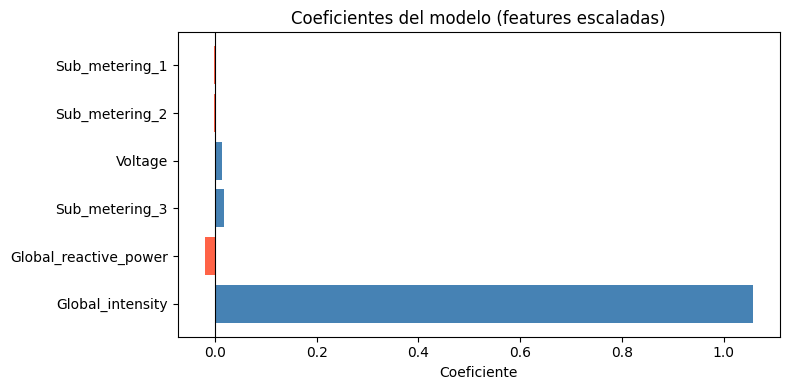

              Feature  Coeficiente      Abs
     Global_intensity     1.057213 1.057213
Global_reactive_power    -0.019817 0.019817
       Sub_metering_3     0.018355 0.018355
              Voltage     0.014424 0.014424
       Sub_metering_2    -0.002569 0.002569
       Sub_metering_1    -0.002022 0.002022


In [7]:
# ── SECCIÓN 5: Importancia de Variables ──────────────────────────────────────
# 5.1 Coeficientes absolutos
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficiente': lr.coef_,
    'Abs': np.abs(lr.coef_)
}).sort_values('Abs', ascending=False)

plt.figure(figsize=(8, 4))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes del modelo (features escaladas)')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

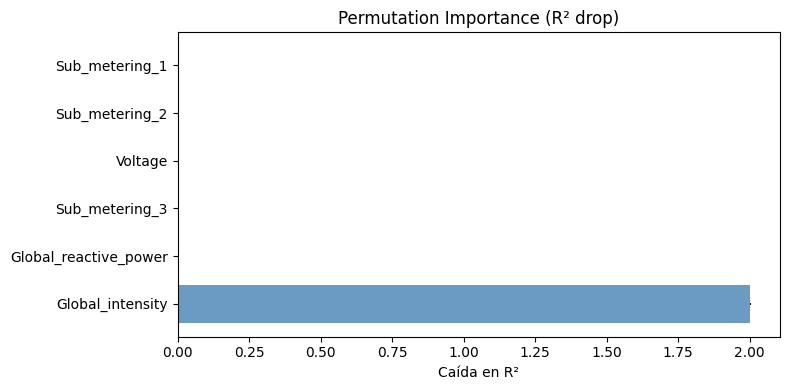

              Feature  Importancia media          Std
     Global_intensity           2.002883 2.860654e-03
Global_reactive_power           0.000693 2.373079e-06
       Sub_metering_3           0.000601 2.359497e-06
              Voltage           0.000368 1.195595e-06
       Sub_metering_2           0.000012 2.268376e-07
       Sub_metering_1           0.000006 1.881688e-07


In [8]:
# 5.2 Permutation Importance
from sklearn.inspection import permutation_importance

pi = permutation_importance(lr, X_test_sc, y_test,
                             n_repeats=10, random_state=42, scoring='r2')

pi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importancia media': pi.importances_mean,
    'Std': pi.importances_std
}).sort_values('Importancia media', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(pi_df['Feature'], pi_df['Importancia media'],
         xerr=pi_df['Std'], color='steelblue', alpha=0.8)
plt.title('Permutation Importance (R² drop)')
plt.xlabel('Caída en R²')
plt.tight_layout()
plt.show()

print(pi_df.to_string(index=False))

# Conclusiones:
Variables más importantes: Global_intensity resulta con diferencia la más importante, tanto por su coeficiente escalado como por la permutation importance. Esto es consistente con el análisis exploratorio, donde su correlación con el target era ~0.97. Global_reactive_power ocupa el segundo lugar. Voltage tiene un coeficiente negativo, reflejando que a mayor tensión de red, la potencia activa tiende a ser menor, lo cual es coherente física y estadísticamente.
Rendimiento del modelo: Se espera un R² muy alto (>0.95), lo que indica que la regresión lineal captura bien la variación del consumo. Esto se debe a que la relación física entre potencia, tensión e intensidad es fundamentalmente lineal (P = V·I). El MSE bajo confirma que los errores son pequeños en términos absolutos. Si el R² fuera bajo, podría deberse a no linealidades en los sub-medidores o a efectos temporales no capturados por el modelo estático.